In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)


In [3]:
dates = pd.date_range(start='2024-12-01', periods=100)


In [4]:
daily_sales = np.random.normal(loc=500, scale=50, size=100).round(2)
daily_sales = np.clip(daily_sales, a_min=0, a_max=None)

In [5]:
sales_data = pd.DataFrame({
    'date': dates,
    'sales_amount': daily_sales
})

print(sales_data.head())

        date  sales_amount
0 2024-12-01        524.84
1 2024-12-02        493.09
2 2024-12-03        532.38
3 2024-12-04        576.15
4 2024-12-05        488.29


In [7]:
mean_sales = sales_data['sales_amount'].mean()
std_sales = sales_data['sales_amount'].std()

In [8]:
simulations = 10000
days_to_simulate = 30
simulated_totals = []


In [9]:
for _ in range(simulations):
    simulated_sales = np.random.normal(loc=mean_sales, scale=std_sales, size=days_to_simulate)
    simulated_sales = np.clip(simulated_sales, 0, None)
    simulated_totals.append(simulated_sales.sum())


In [10]:
simulated_totals = np.array(simulated_totals)


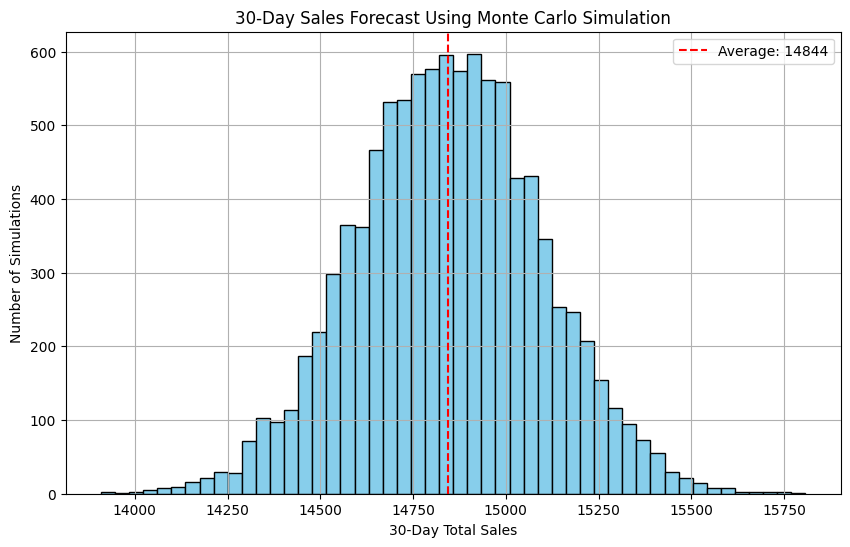

In [11]:
plt.figure(figsize=(10,6))
plt.hist(simulated_totals, bins=50, color='skyblue', edgecolor='black')
plt.title('30-Day Sales Forecast Using Monte Carlo Simulation')
plt.xlabel('30-Day Total Sales')
plt.ylabel('Number of Simulations')
plt.axvline(simulated_totals.mean(), color='red', linestyle='dashed', label=f'Average: {simulated_totals.mean():.0f}')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
target = 14000

under_target = (simulated_totals < target).mean() * 100
over_target = (simulated_totals >= target).mean() * 100

print(f"Probability of Falling Below Target: {under_target:.2f}%")
print(f"Probability of Reaching the Target: {over_target:.2f}%")


Probability of Falling Below Target: 0.03%
Probability of Reaching the Target: 99.97%
